# Mounting The Drive

In [ ]:
from skimage import io  # has functions to read and write images
from skimage import color as change  # contains function to change between color spaces
from pathlib import Path
import os
import shutil

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)

    base_dir = Path("/content/MGC_project")
    drive_root = Path("/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped/Data")
else:
    base_dir = Path.cwd().parent
    drive_root = None

data_dir = base_dir / "data"
raw_data_dir = data_dir / "raw"
feature_dir = data_dir / "features"
runtime_dir = data_dir / "runtime"
checkpoint_dir = base_dir / "checkpoints"
saved_model_dir = base_dir / "saved_model"

for p in [data_dir, raw_data_dir, feature_dir, runtime_dir, checkpoint_dir, saved_model_dir]:
    p.mkdir(parents=True, exist_ok=True)

# Dataset paths
genres_dst = raw_data_dir / "Data" / "genres_original"
images_dst = raw_data_dir / "Data" / "images_original"

genres_dst.parent.mkdir(parents=True, exist_ok=True)
images_dst.parent.mkdir(parents=True, exist_ok=True)

if IN_COLAB:
    genres_src = drive_root / "genres_original"
    images_src = drive_root / "images_original"

    if not genres_dst.exists():
        print("Copying genres_original to local VM...")
        shutil.copytree(genres_src, genres_dst)
        print("Copy complete.")
    else:
        print("genres_original already exists locally.")

    if images_src.exists():
        if not images_dst.exists():
            print("Copying images_original...")
            shutil.copytree(images_src, images_dst)
            print("Image copy complete.")
        else:
            print("images_original already exists locally.")
else:
    print("Running locally. Expect dataset under:")
    print(genres_dst)
    print(images_dst)

print("Base:", base_dir)
print("Raw data root:", raw_data_dir)
print("Genres path:", genres_dst)
print("Images path:", images_dst)

Mounted at /content/drive
Copying genres_original to local VM...
Copy complete.
Copying images_original...
Image copy complete.
Base: /content/MGC_project
Raw data root: /content/MGC_project/data/raw
Genres path: /content/MGC_project/data/raw/Data/genres_original
Images path: /content/MGC_project/data/raw/Data/images_original


# Installing libraries and dependencies

In [ ]:
import torch
from torch import nn
from torch.utils.data import ConcatDataset, DataLoader
import numpy as np
# print("GPU:",torch.cuda.get_device_name(0))

import time

import torchvision
import torchvision.models as models
from torchvision import transforms

from PIL import Image
import matplotlib.pyplot as plt

!pip install nvidia-ml-py
import psutil

!pip install pynvml
import pynvml

!pip install thop
from thop import profile
from thop import clever_format

import warnings
warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 651.1 kB/s eta 0:00:00


## Download File from Kaggle, Read, and Unzip GTZAN zip File

In [ ]:
import sys
import zipfile
import shutil
from pathlib import Path

!{sys.executable} -m pip install -q -U kagglehub
import kagglehub

DATASET_SLUG = "andradaolteanu/gtzan-dataset-music-genre-classification"

def ensure_gtzan(data_dir, zip_file="gtzan_data.zip"):
    data_dir = Path(data_dir)
    zip_path = data_dir / zip_file

    genres_dir = data_dir / "genres_original"
    sentinel = genres_dir / "blues" / "blues.00000.wav"

    print(f"Expected zip path: {zip_path}")
    print(f"Target folder:      {genres_dir}")

    # 1) Already ready?
    if sentinel.exists():
        return True, "Dataset already available at", str(genres_dir)

    data_dir.mkdir(parents=True, exist_ok=True)

    # 2) If zip exists locally, unzip it into data_dir
    if zip_path.exists() and zipfile.is_zipfile(zip_path):
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(data_dir)

        if sentinel.exists():
            return True, "Extraction complete from zip to", str(genres_dir)

        return False, "Zip extracted but sentinel not found in", str(data_dir)

    # 3) Otherwise download via kagglehub
    cache_dir = Path(kagglehub.dataset_download(DATASET_SLUG))
    print("Kagglehub cache path:", cache_dir)

    # Copy cache contents into data_dir
    for item in cache_dir.iterdir():
        dest = data_dir / item.name
        if dest.exists():
            continue
        if item.is_dir():
            shutil.copytree(item, dest)
        else:
            shutil.copy2(item, dest)

    if sentinel.exists():
        return True, "Copied from kagglehub cache to", str(genres_dir)

    return False, "Downloaded but expected GTZAN layout not found in", str(data_dir)

# ---- Run it ----
ok, msg, where = ensure_gtzan(raw_data_dir)
print(msg, where)

Expected zip path: /content/MGC_project/data/raw/gtzan_data.zip
Target folder:      /content/MGC_project/data/raw/genres_original


100%|██████████| 1.21G/1.21G [01:03<00:00, 20.5MB/s]

Extracting files...


Kagglehub cache path: /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1
Downloaded but expected GTZAN layout not found in /content/MGC_project/data/raw


# Music Genre Classification

1. Suggested dataset: GTZAN Dataset

2. Model: CNN (you can use an existing model, or choose to implement your own)

3. Summary: Classify music into genres like rock, classical, jazz, etc., using
spectrograms derived from audio signals.

4. Reasoning: Spectrograms transform audio into image-like data, and CNNs excel
in image feature extraction and classification.

5. Implementation:

   * § Your model has to be trained and tested on both CPU and GPU.

   * § CPU: Precompute spectrograms offline to reduce real-time computation.

   * § GPU: Train CNN models directly on spectrogram data for faster convergence.

6. Expected Results: Classification accuracy of 70-90%.


## Check the unzip data successfully by listing all the folders

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped/" | head
!ls "/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped/Data/genres_original/" | head
!find "/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped" -type d -iname "genres_original" -print
!ls -la "/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped/Data" | head -n 50
!ls -ld "/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped/Data/"


Data
blues
classical
country
disco
hiphop
jazz
metal
pop
reggae
rock
/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped/Data/genres_original
total 11906
-rw-------  1 root root  1108271 Feb 25 01:36 features_30_sec.csv
-rw-------  1 root root 11075018 Feb 25 01:36 features_3_sec.csv
drwx------ 12 root root     4096 Feb 25 01:35 genres_original
drwx------ 12 root root     4096 Feb 25 02:05 images_original
drwx------ 4 root root 4096 Feb 25 02:05 '/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped/Data/'


---

## GPU energy helper

In [ ]:
def get_energy_reading():
    try:
        if torch.cuda.is_available():
            return get_current_energy()   # returns mJ from your earlier helper
    except Exception:
        pass
    return None

def energy_used_joules(start_mj, end_mj):
    if start_mj is None or end_mj is None:
        return None
    return (end_mj - start_mj) * 1e-3

## GPU info snapshot block

*   Before training
*   After training


In [ ]:
def print_gpu_snapshot():
    try:
        if torch.cuda.is_available():
            gpu = get_gpu_info()
            print("GPU Snapshot:")
            for k, v in gpu.items():
                print(f"{k}: {v}")
    except Exception as e:
        print(f"GPU snapshot unavailable: {e}")

## Load GTZAN wave files and separate them into lists

### With corrupted file handling, slower, but excluding any corrupted file(s)

In [ ]:
print(raw_data_dir)
print(raw_data_dir.exists())
print((raw_data_dir / "genres_original").exists())

print("raw_data_dir:", raw_data_dir)
print("raw exists:", raw_data_dir.exists())

if raw_data_dir.exists():
    print("contents of raw_data_dir:")
    for p in raw_data_dir.iterdir():
        print(" -", p)

/content/MGC_project/data/raw
True
False
raw_data_dir: /content/MGC_project/data/raw
raw exists: True
contents of raw_data_dir:
 - /content/MGC_project/data/raw/Data


In [ ]:
from pathlib import Path
import librosa

def load_gtzan_dataset_split(base_dir):
    base_path = Path(base_dir)

    count_folders = 0
    count_files_in_folder = 0
    count_valid_files = 0
    count_bad_files = 0

    files = []
    labels = []

    for genre_dir in base_path.iterdir():
        if genre_dir.is_dir():
            genre = genre_dir.name
            count_folders += 1
            print(f"Processing genre: {genre}")

            for audio_file in genre_dir.glob("*.wav"):
                count_files_in_folder += 1

                try:
                    # Try loading a short portion (faster than full load)
                    y, sr = librosa.load(audio_file, sr=None, duration=1.0)

                    # Optional: check if audio is empty
                    if y is None or len(y) == 0:
                        raise ValueError("Empty audio")

                    files.append(str(audio_file))
                    labels.append(genre)
                    count_valid_files += 1

                except Exception as e:
                    print(f"Skipping corrupted file: {audio_file}")
                    count_bad_files += 1

    print(f"\nTotal folders: {count_folders}")
    print(f"Total files found: {count_files_in_folder}")
    print(f"Valid files: {count_valid_files}")
    print(f"Corrupted files skipped: {count_bad_files}")

    return files, labels
base_dir = raw_data_dir / "Data" / "genres_original"
file_list = load_gtzan_dataset_split(base_dir)

print("Total files:", len(file_list))
print("Sample:", file_list[:5])

Processing genre: rock
Processing genre: reggae
Processing genre: blues
Processing genre: metal
Processing genre: pop
Processing genre: classical
Processing genre: disco
Processing genre: jazz
Skipping corrupted file: /content/MGC_project/data/raw/Data/genres_original/jazz/jazz.00054.wav
Processing genre: country
Processing genre: hiphop

Total folders: 10
Total files found: 986
Valid files: 985
Corrupted files skipped: 1
Total files: 2
Sample: (['/content/MGC_project/data/raw/Data/genres_original/rock/rock.00093.wav', '/content/MGC_project/data/raw/Data/genres_original/rock/rock.00042.wav', '/content/MGC_project/data/raw/Data/genres_original/rock/rock.00003.wav', '/content/MGC_project/data/raw/Data/genres_original/rock/rock.00037.wav', '/content/MGC_project/data/raw/Data/genres_original/rock/rock.00035.wav', '/content/MGC_project/data/raw/Data/genres_original/rock/rock.00030.wav', '/content/MGC_project/data/raw/Data/genres_original/rock/rock.00025.wav', '/content/MGC_project/data/raw/

# Student

## Imports

In [ ]:
import os
import gc
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

## Configuration

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

SR = 22050
WINDOW_SECONDS = 3.0
WINDOW_SAMPLES = int(SR * WINDOW_SECONDS)

N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 512

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
NUM_CLASSES = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


## Timing helper

In [ ]:
def now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.time()

## Load GTZAN file paths

### 1. Remove metadata columns: (filename, length, and label)

In [ ]:
def load_gtzan_file_paths(base_dir):
    base_path = Path(base_dir)
    filepaths = []
    labels = []

    for genre_dir in sorted(base_path.iterdir()):
        if genre_dir.is_dir():
            genre = genre_dir.name
            for audio_file in sorted(genre_dir.glob("*.wav")):
                filepaths.append(str(audio_file))
                labels.append(genre)

    df = pd.DataFrame({
        "filepath": filepaths,
        "label": labels
    })
    return df

## Stratified track split

In [ ]:
def stratified_track_split(df, test_size=0.2, val_size=0.1, random_state=42):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df["label"],
        random_state=random_state
    )

    adjusted_val_size = val_size / (1.0 - test_size)

    train_df, val_df = train_test_split(
        train_df,
        test_size=adjusted_val_size,
        stratify=train_df["label"],
        random_state=random_state
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True)
    )

## Safe audio loading

In [ ]:
def load_audio_safe(filepath, sr=SR, normalize=True):
    try:
        y, sr_loaded = librosa.load(filepath, sr=sr, mono=True)

        if y is None or len(y) == 0:
            return None, None, f"Empty audio: {filepath}"

        if not np.all(np.isfinite(y)):
            return None, None, f"Non-finite audio samples: {filepath}"

        if normalize:
            peak = np.max(np.abs(y))
            if peak > 0:
                y = y / peak

        return y.astype(np.float32), sr_loaded, None

    except Exception as e:
        return None, None, f"{type(e).__name__}: {str(e)}"

## Segment metadata builder

In [ ]:
def build_segment_table_safe(df, split_name, hop_samples=None, failed_files=None):
    rows = []

    if failed_files is None:
        failed_files = []

    if hop_samples is None:
        hop_samples = WINDOW_SAMPLES

    for _, row in df.iterrows():
        filepath = row["filepath"]
        label = row["label"]

        y, sr_loaded, err = load_audio_safe(filepath, sr=SR)

        if err is not None:
            failed_files.append(filepath)
            continue

        if len(y) < WINDOW_SAMPLES:
            rows.append({
                "filepath": filepath,
                "label": label,
                "split": split_name,
                "segment_index": 0,
                "start_sample": 0,
                "end_sample": WINDOW_SAMPLES
            })
            continue

        seg_idx = 0
        for start in range(0, len(y) - WINDOW_SAMPLES + 1, hop_samples):
            end = start + WINDOW_SAMPLES
            rows.append({
                "filepath": filepath,
                "label": label,
                "split": split_name,
                "segment_index": seg_idx,
                "start_sample": start,
                "end_sample": end
            })
            seg_idx += 1

    seg_df = pd.DataFrame(rows)
    return seg_df, failed_files

## Augmentation helpers

In [ ]:
def add_noise(y, noise_factor=0.003):
    noise = np.random.randn(len(y)).astype(np.float32)
    y_noisy = y + noise_factor * noise
    return np.clip(y_noisy, -1.0, 1.0).astype(np.float32)

def time_shift(y, shift_max=0.2):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    return np.roll(y, shift).astype(np.float32)

def pitch_shift_audio(y, sr=SR, n_steps_range=(-1.0, 1.0)):
    n_steps = np.random.uniform(n_steps_range[0], n_steps_range[1])
    y_shifted = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    return y_shifted.astype(np.float32)

def time_stretch_audio(y, rate_range=(0.9, 1.1)):
    rate = np.random.uniform(rate_range[0], rate_range[1])
    y_stretch = librosa.effects.time_stretch(y, rate=rate)

    if len(y_stretch) > WINDOW_SAMPLES:
        y_stretch = y_stretch[:WINDOW_SAMPLES]
    else:
        y_stretch = np.pad(y_stretch, (0, max(0, WINDOW_SAMPLES - len(y_stretch))))

    return y_stretch.astype(np.float32)

def apply_random_augmentation(y, sr=SR):
    aug_choice = np.random.choice(["none", "noise", "shift", "pitch", "stretch"])

    if aug_choice == "noise":
        y = add_noise(y)
    elif aug_choice == "shift":
        y = time_shift(y)
    elif aug_choice == "pitch":
        y = pitch_shift_audio(y, sr=sr)
    elif aug_choice == "stretch":
        y = time_stretch_audio(y)

    return y.astype(np.float32)

## Build a dataset that read .npy features from /content

In [ ]:
# 2. Custom Dataset class  ← PUT IT HERE
class LogMelNPYDataset(Dataset):
    def __init__(self, samples, label_to_idx, cache_in_ram=False):
        self.samples = samples
        self.label_to_idx = label_to_idx
        self.cache_in_ram = cache_in_ram
        self.cache = {}

        if self.cache_in_ram:
            print("Caching features into RAM...")
            for path, label in self.samples:
                arr = np.load(path).astype(np.float32)
                self.cache[path] = arr
            print("RAM caching complete.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        if self.cache_in_ram:
            feat = self.cache[path]
        else:
            feat = np.load(path).astype(np.float32)

        feat = torch.tensor(feat, dtype=torch.float32).unsqueeze(0)
        target = torch.tensor(self.label_to_idx[label], dtype=torch.long)

        return feat, target

## Log-mel extraction

In [ ]:
import shutil
import time
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np
import os

optimized_out = feature_dir / "logmel"
serial_out = feature_dir / "logmel_test_serial"
parallel_out = feature_dir / "logmel_test_parallel"

# Clean only test folders
shutil.rmtree(serial_out, ignore_errors=True)
shutil.rmtree(parallel_out, ignore_errors=True)

serial_out.mkdir(parents=True, exist_ok=True)
parallel_out.mkdir(parents=True, exist_ok=True)

# Build same task list
all_wavs = []
for genre_dir in genres:
    for fname in os.listdir(genre_dir):
        if fname.lower().endswith(".wav"):
            all_wavs.append(genre_dir / fname)

def save_logmel_to_root_safe(in_path, root_out):
    genre = in_path.parent.name
    out_dir = root_out / genre
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"{in_path.stem}.npy"

    try:
        feat = extract_logmel(in_path)
        np.save(str(out_path), feat)
        return ("saved", str(in_path))
    except Exception as e:
        return ("failed", f"{in_path} -> {e}")

#### Serial timing ####
serial_results = []

t0 = time.perf_counter()

for in_path in tqdm(all_wavs, desc="Serial extraction"):
    serial_results.append(save_logmel_to_root_safe(in_path, serial_out))

t1 = time.perf_counter()
serial_time = t1 - t0

serial_saved = sum(r[0] == "saved" for r in serial_results)
serial_failed = [r[1] for r in serial_results if r[0] == "failed"]

print(f"Serial time: {serial_time:.2f} sec")
print("Serial saved:", serial_saved)
print("Serial failed:", len(serial_failed))
print(serial_failed[:5])

#### Parallel timing ####
t0 = time.perf_counter()

parallel_results = Parallel(n_jobs=4, backend="loky")(
    delayed(save_logmel_to_root_safe)(in_path, parallel_out)
    for in_path in tqdm(all_wavs, desc="Parallel extraction")
)

t1 = time.perf_counter()
parallel_time = t1 - t0

parallel_saved = sum(r[0] == "saved" for r in parallel_results)
parallel_failed = [r[1] for r in parallel_results if r[0] == "failed"]

print(f"Parallel time: {parallel_time:.2f} sec")
print("Parallel saved:", parallel_saved)
print("Parallel failed:", len(parallel_failed))
print(parallel_failed[:5])

#### Comparison + keep optimized ####
speedup = serial_time / parallel_time
efficiency = speedup / 4

print(f"Speedup: {speedup:.2f}x")
print(f"Parallel efficiency: {efficiency:.2%}")

# Keep the faster output as final optimized logmel folder
winner_out = parallel_out if parallel_time < serial_time else serial_out
winner_name = "parallel" if parallel_time < serial_time else "serial"

shutil.rmtree(optimized_out, ignore_errors=True)
shutil.copytree(winner_out, optimized_out)

print(f"Kept {winner_name} output as optimized features:")
print(optimized_out)

Serial extraction: 100%|██████████| 986/986 [00:21<00:00, 46.65it/s]


Serial time: 21.14 sec
Serial saved: 985
Serial failed: 1
['/content/MGC_project/data/raw/Data/genres_original/jazz/jazz.00054.wav -> ']


Parallel extraction: 100%|██████████| 986/986 [00:19<00:00, 50.06it/s] 


Parallel time: 19.98 sec
Parallel saved: 985
Parallel failed: 1
['/content/MGC_project/data/raw/Data/genres_original/jazz/jazz.00054.wav -> ']
Speedup: 1.06x
Parallel efficiency: 26.46%
Kept parallel output as optimized features:
/content/MGC_project/data/features/logmel


## Build all_samples and split

In [ ]:
from sklearn.model_selection import train_test_split
import os

features_root = feature_dir / "logmel"

# convert to string only if needed
features_root_str = str(features_root)

genres = sorted([
    d for d in os.listdir(features_root_str)
    if os.path.isdir(os.path.join(features_root_str, d))
])

label_to_idx = {g: i for i, g in enumerate(genres)}

all_samples = []
for genre in genres:
    genre_dir = os.path.join(features_root_str, genre)
    for fname in os.listdir(genre_dir):
        if fname.endswith(".npy"):
            all_samples.append((os.path.join(genre_dir, fname), genre))

train_samples, temp_samples = train_test_split(
    all_samples,
    test_size=0.3,
    stratify=[label for _, label in all_samples],
    random_state=42
)

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=2/3,
    stratify=[label for _, label in temp_samples],
    random_state=42
)

print("Train:", len(train_samples))
print("Val:", len(val_samples))
print("Test:", len(test_samples))

Train: 689
Val: 98
Test: 198


## Compute log mel spectrogram

In [ ]:
def compute_log_mel_spectrogram(y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    log_mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    return log_mel

## Save precomputed features to disk

## Put the parallel logic inside save_precomputed_logmels()

In [ ]:
from joblib import Parallel, delayed
from pathlib import Path
import pandas as pd
import numpy as np

def save_one_segment(idx, row, output_dir, augment=False):
    filepath = row["filepath"]
    label = row["label"]
    split = row["split"]
    segment_index = int(row["segment_index"])
    start_sample = int(row["start_sample"])
    end_sample = int(row["end_sample"])

    local_records = []
    local_failed = []

    y, sr_loaded, err = load_audio_safe(filepath, sr=SR)
    if err is not None:
        local_failed.append(filepath)
        return local_records, local_failed

    segment = y[start_sample:end_sample]

    if len(segment) < WINDOW_SAMPLES:
        segment = np.pad(segment, (0, WINDOW_SAMPLES - len(segment)))

    versions = [("orig", segment)]

    if augment:
        versions.append(("aug", apply_random_augmentation(segment, sr=SR)))

    for version_name, version_audio in versions:
        try:
            log_mel = compute_log_mel_spectrogram(version_audio)

            if not np.all(np.isfinite(log_mel)):
                local_failed.append(filepath)
                continue

            out_name = f"{split}_{idx:06d}_seg{segment_index:02d}_{version_name}.npy"
            out_path = output_dir / out_name

            np.save(out_path, log_mel)

            local_records.append({
                "feature_path": str(out_path),
                "label": label,
                "split": split,
                "segment_index": segment_index,
                "source_filepath": filepath,
                "version": version_name
            })

        except Exception as e:
            print(
                f"Failed feature save for {filepath}, "
                f"version={version_name}: {type(e).__name__}: {e}"
            )
            local_failed.append(filepath)

    return local_records, local_failed

def save_precomputed_logmels(
    seg_df,
    output_dir,
    augment=False,
    failed_files=None,
    n_jobs=4
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if failed_files is None:
        failed_files = []

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(save_one_segment)(idx, row, output_dir, augment)
        for idx, row in seg_df.iterrows()
    )

    records = []

    for local_records, local_failed in results:
        records.extend(local_records)
        failed_files.extend(local_failed)

    manifest_df = pd.DataFrame(records)

    if len(seg_df) > 0:
        split_name = seg_df["split"].iloc[0]
    else:
        split_name = "empty"

    manifest_path = output_dir / f"{split_name}_manifest.csv"
    manifest_df.to_csv(manifest_path, index=False)

    return manifest_df, failed_files

def save_precomputed_logmels(
    seg_df,
    output_dir,
    augment=False,
    failed_files=None,
    n_jobs=4
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if failed_files is None:
        failed_files = []

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(save_one_segment)(idx, row, output_dir, augment)
        for idx, row in seg_df.iterrows()
    )

    records = []

    for local_records, local_failed in results:
        records.extend(local_records)
        failed_files.extend(local_failed)

    manifest_df = pd.DataFrame(records)

    if len(seg_df) > 0:
        split_name = seg_df["split"].iloc[0]
    else:
        split_name = "empty"

    manifest_path = output_dir / f"{split_name}_manifest.csv"
    manifest_df.to_csv(manifest_path, index=False)

    return manifest_df, failed_files

## Compute normalization stats from saved train features

In [ ]:
def compute_saved_feature_mean_std(manifest_df, max_samples=None, seed=SEED):
    if max_samples is not None and len(manifest_df) > max_samples:
        manifest_df = manifest_df.sample(n=max_samples, random_state=seed).reset_index(drop=True)

    feature_list = []

    for _, row in manifest_df.iterrows():
        x = np.load(row["feature_path"]).astype(np.float32)
        feature_list.append(x)

    X = np.stack(feature_list)
    mean = X.mean()
    std = X.std()
    std = max(std, 1e-8)

    del X, feature_list
    gc.collect()

    return mean, std

## Save-feature dataset

In [ ]:
class SavedLogMelDataset(Dataset):
    def __init__(self, manifest_df, label_encoder, mean, std, cache_in_ram=False):
        self.manifest_df = manifest_df.reset_index(drop=True)
        self.label_encoder = label_encoder
        self.mean = mean
        self.std = std
        self.cache_in_ram = cache_in_ram
        self.cache = {}

        if self.cache_in_ram:
            print("Caching features into RAM...")
            for i, row in self.manifest_df.iterrows():
                x = np.load(row["feature_path"]).astype(np.float32)
                x = (x - self.mean) / self.std
                y = self.label_encoder.transform([row["label"]])[0]
                self.cache[i] = (x, y)
            print("RAM caching complete.")

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, idx):
        if self.cache_in_ram:
            x, y = self.cache[idx]
        else:
            row = self.manifest_df.iloc[idx]
            x = np.load(row["feature_path"]).astype(np.float32)
            x = (x - self.mean) / self.std
            y = self.label_encoder.transform([row["label"]])[0]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)
        return x, y

## Dataloader creation

In [ ]:
def create_dataloaders(
    train_manifest_df,
    val_manifest_df,
    test_manifest_df,
    label_encoder,
    mean,
    std,
    batch_size=BATCH_SIZE
):
    train_dataset = SavedLogMelDataset(train_manifest_df, label_encoder, mean, std, cache_in_ram=True)
    val_dataset   = SavedLogMelDataset(val_manifest_df, label_encoder, mean, std, cache_in_ram=False)
    test_dataset  = SavedLogMelDataset(test_manifest_df, label_encoder, mean, std, cache_in_ram=False)

    use_cuda = torch.cuda.is_available()
    # num_workers = 0 if os.name == 'nt' else 4

    num_workers = 2   # force parallelize

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=use_cuda,
        persistent_workers=(num_workers > 0)
    )

    import time

    t0 = time.time()
    xb, yb = next(iter(train_loader))
    t1 = time.time()

    print("One batch load time:", t1 - t0)
    print("xb shape:", xb.shape)
    print("yb shape:", yb.shape)

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=use_cuda,
        persistent_workers=(num_workers > 0)
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=use_cuda,
        persistent_workers=(num_workers > 0)
    )

    return train_loader, val_loader, test_loader

## Compact 1D CNN student

In [ ]:
class CompactMusicGenreCNN1D(nn.Module):
    def __init__(self, n_mels=N_MELS, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_mels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model Mod 1

In [ ]:
import torch
import torch.nn as nn

class DSConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class MGCStudentMobile(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            DSConvBlock(1, 8, stride=2),
            DSConvBlock(8, 16, stride=2),
            DSConvBlock(16, 32, stride=2),
            DSConvBlock(32, 64, stride=2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Training function


In [ ]:
from tqdm.auto import tqdm
import time
import torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for inputs, labels in progress_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        avg_loss = total_loss / total
        avg_acc = correct / total

        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "acc": f"{avg_acc:.4f}"
        })

    total_time = time.time() - start_time
    avg_loss = total_loss / total
    avg_acc = correct / total

    total_energy = None
    return avg_loss, avg_acc, total_time, total_energy

## Validation function

In [ ]:
from tqdm.auto import tqdm
import time
import torch

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    progress_bar = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            avg_loss = total_loss / total
            avg_acc = correct / total

            progress_bar.set_postfix({
                "val_loss": f"{avg_loss:.4f}",
                "val_acc": f"{avg_acc:.4f}"
            })

    total_time = time.time() - start_time
    avg_loss = total_loss / total
    avg_acc = correct / total

    total_energy = None
    return avg_loss, avg_acc, total_time, total_energy

## Test function

In [ ]:
def test_model(model, loader, device):
    model.eval()

    start_time = now()
    start_energy = get_energy_reading()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    end_time = now()
    end_energy = get_energy_reading()

    total_time = end_time - start_time
    total_energy = energy_used_joules(start_energy, end_energy)

    return np.array(all_targets), np.array(all_preds), total_time, total_energy

## Early stopping helper

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return False

        improved = (
            current_score > self.best_score if self.mode == "max"
            else current_score < self.best_score
        )

        if improved:
            self.best_score = current_score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

## Precompute preprocessing block

In [ ]:
# base_dir = "/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_gtzan/gtzan_unzipped/Data/genres_original"
# precompute_dir = "/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_precomputed_logmel"

import time


# --- LOCAL / PORTABLE STORAGE ---
base_dir = raw_data_dir / "Data" / "genres_original"
precompute_dir = feature_dir / "precomputed_logmel"

df = load_gtzan_file_paths(base_dir)
train_df, val_df, test_df = stratified_track_split(df)

failed_files = []

start_time = time.time()
preprocess_start = now()

train_seg_df, failed_files = build_segment_table_safe(train_df, split_name="train", failed_files=failed_files)
val_seg_df, failed_files = build_segment_table_safe(val_df, split_name="val", failed_files=failed_files)
test_seg_df, failed_files = build_segment_table_safe(test_df, split_name="test", failed_files=failed_files)

print("Train segments:", len(train_seg_df))
print("Val segments:", len(val_seg_df))
print("Test segments:", len(test_seg_df))
print("Initial failed files:", len(failed_files))

train_manifest_df, failed_files = save_precomputed_logmels(
    train_seg_df,
    output_dir=precompute_dir,
    augment=True,
    failed_files=failed_files
)

val_manifest_df, failed_files = save_precomputed_logmels(
    val_seg_df,
    output_dir=precompute_dir,
    augment=False,
    failed_files=failed_files
)

test_manifest_df, failed_files = save_precomputed_logmels(
    test_seg_df,
    output_dir=precompute_dir,
    augment=False,
    failed_files=failed_files
)

print("Saved train samples:", len(train_manifest_df))
print("Saved val samples:", len(val_manifest_df))
print("Saved test samples:", len(test_manifest_df))
print("Total failed files:", len(set(failed_files)))

label_encoder = LabelEncoder()
label_encoder.fit(train_df["label"])

mean, std = compute_saved_feature_mean_std(train_manifest_df, max_samples=2000)
if len(train_manifest_df) == 0:
    raise RuntimeError("train_manifest_df is empty. Precompute step failed; check earlier error messages.")

print("Train feature mean:", mean)
print("Train feature std:", std)

stats_path = Path(precompute_dir) / "normalization_stats.json"
with open(stats_path, "w") as f:
    json.dump({"mean": float(mean), "std": float(std)}, f)

label_map_path = Path(precompute_dir) / "label_classes.json"
with open(label_map_path, "w") as f:
    json.dump(label_encoder.classes_.tolist(), f)

failures_df = pd.DataFrame({"failed_filepath": sorted(set(failed_files))})
if len(failures_df) > 0:
    failures_df.to_csv(Path(precompute_dir) / "audio_load_failures.csv", index=False)
    print(failures_df.head(10))
else:
    print("No audio loading failures.")

preprocess_end = now()
print(f"Precompute time: {preprocess_end - preprocess_start:.2f} sec")

end_time = time.time()
print(f"Total time: {end_time - start_time:.2f} sec")

Train segments: 6873
Val segments: 988
Test segments: 1980
Initial failed files: 1
Saved train samples: 13746
Saved val samples: 988
Saved test samples: 1980
Total failed files: 1
Train feature mean: -36.814484
Train feature std: 15.068079
                                     failed_filepath
0  /content/MGC_project/data/raw/Data/genres_orig...
Precompute time: 425.10 sec
Total time: 425.10 sec


## Create Dataloaders from save features

In [ ]:
train_manifest_path = Path(precompute_dir) / "train_manifest.csv"
val_manifest_path = Path(precompute_dir) / "val_manifest.csv"
test_manifest_path = Path(precompute_dir) / "test_manifest.csv"

train_manifest_df = pd.read_csv(train_manifest_path)
val_manifest_df = pd.read_csv(val_manifest_path)
test_manifest_df = pd.read_csv(test_manifest_path)

with open(Path(precompute_dir) / "normalization_stats.json", "r") as f:
    stats = json.load(f)

mean = stats["mean"]
std = stats["std"]

with open(Path(precompute_dir) / "label_classes.json", "r") as f:
    label_classes = json.load(f)

label_encoder = LabelEncoder()
label_encoder.fit(label_classes)

train_loader, val_loader, test_loader = create_dataloaders(
    train_manifest_df=train_manifest_df,
    val_manifest_df=val_manifest_df,
    test_manifest_df=test_manifest_df,
    label_encoder=label_encoder,
    mean=mean,
    std=std,
    batch_size=BATCH_SIZE
)

print("Train dataset size:", len(train_loader.dataset))
print("Val dataset size:", len(val_loader.dataset))
print("Test dataset size:", len(test_loader.dataset))

sample_x, sample_y = train_loader.dataset[0]
print("Sample tensor shape:", sample_x.shape)
print("Sample label:", sample_y)

Caching features into RAM...
RAM caching complete.
One batch load time: 0.21497869491577148
xb shape: torch.Size([32, 64, 130])
yb shape: torch.Size([32])
Train dataset size: 13746
Val dataset size: 988
Test dataset size: 1980
Sample tensor shape: torch.Size([64, 130])
Sample label: tensor(9)


## Checkpoint save

In [ ]:
def save_checkpoint(
    checkpoint_path,
    model,
    optimizer,
    epoch,
    best_val_acc,
    history,
    early_stopper=None,
    scheduler=None
):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history
    }

    if scheduler is not None:
        checkpoint["scheduler_state_dict"] = scheduler.state_dict()

    if early_stopper is not None:
        checkpoint["early_stopper"] = {
            "patience": early_stopper.patience,
            "mode": early_stopper.mode,
            "best_score": early_stopper.best_score,
            "counter": early_stopper.counter,
            "should_stop": early_stopper.should_stop
        }

    torch.save(checkpoint, checkpoint_path)

## Checkpoint load function

In [ ]:
def load_checkpoint(
    checkpoint_path,
    model,
    optimizer=None,
    scheduler=None,
    device=DEVICE
):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    epoch = checkpoint.get("epoch", -1)
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    history = checkpoint.get("history", {})

    early_state = checkpoint.get("early_stopper", None)

    return epoch, best_val_acc, history, early_state

## Restore early stopper helper

In [ ]:
def restore_early_stopper(early_state):
    if early_state is None:
        return EarlyStopping(patience=5, mode="max")

    stopper = EarlyStopping(
        patience=early_state["patience"],
        mode=early_state["mode"]
    )
    stopper.best_score = early_state["best_score"]
    stopper.counter = early_state["counter"]
    stopper.should_stop = early_state["should_stop"]

    return stopper

## Training block

In [ ]:
import os
import shutil

# --- LOCAL (FAST) STORAGE ---
local_checkpoint_dir = "/checkpoints"

# --- GOOGLE DRIVE (PERSISTENT STORAGE) --- Colab local drive
drive_checkpoint_dir = "/content/MGC_project/checkpoints"

os.makedirs(local_checkpoint_dir, exist_ok=True)
os.makedirs(drive_checkpoint_dir, exist_ok=True)

best_model_path = os.path.join(local_checkpoint_dir, "best_mgc_student_1dcnn_logmel.pth")
checkpoint_path = os.path.join(local_checkpoint_dir, "latest_checkpoint_1dcnn.pth")

model = CompactMusicGenreCNN1D(
    n_mels=N_MELS,
    num_classes=len(label_encoder.classes_)
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

start_epoch = 0
best_val_acc = 0.0
early_stopper = EarlyStopping(patience=5, mode="max")

history = {
    "train_loss": [],
    "train_acc": [],
    "train_time": [],
    "train_energy": [],
    "val_loss": [],
    "val_acc": [],
    "val_time": [],
    "val_energy": []
}

resume_training = False   # safer unless you restore local checkpoint from Drive first

if resume_training and os.path.exists(checkpoint_path):
    loaded_epoch, best_val_acc, loaded_history, early_state = load_checkpoint(
        checkpoint_path,
        model,
        optimizer=optimizer,
        device=DEVICE
    )

    start_epoch = loaded_epoch + 1
    history = loaded_history
    early_stopper = restore_early_stopper(early_state)

    print(f"Resumed from epoch {start_epoch}")
    print(f"Best validation accuracy so far: {best_val_acc:.4f}")
else:
    print("Starting fresh training run.")

if start_epoch >= EPOCHS:
    print("Training already completed. Resetting to start from scratch.")
    start_epoch = 0
    best_val_acc = 0.0
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_time": [],
        "train_energy": [],
        "val_loss": [],
        "val_acc": [],
        "val_time": [],
        "val_energy": []
    }
    early_stopper = EarlyStopping(patience=5, mode="max")

epoch_bar = tqdm(range(start_epoch, EPOCHS), desc="Epochs")

for epoch in epoch_bar:
    train_loss, train_acc, train_time, train_energy = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_acc, val_time, val_energy = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_time"].append(train_time)
    history["train_energy"].append(train_energy)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_time"].append(val_time)
    history["val_energy"].append(val_energy)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved new best model at epoch {epoch+1}")

    early_stopper.step(val_acc)

    save_checkpoint(
        checkpoint_path=checkpoint_path,
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        best_val_acc=best_val_acc,
        history=history,
        early_stopper=early_stopper
    )

    if (epoch + 1) % 5 == 0:
        epoch_checkpoint_path = os.path.join(
            local_checkpoint_dir,
            f"checkpoint_epoch_{epoch+1}.pth"
        )
        save_checkpoint(
            checkpoint_path=epoch_checkpoint_path,
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            best_val_acc=best_val_acc,
            history=history,
            early_stopper=early_stopper
        )
        print(f"Saved interval checkpoint: {epoch_checkpoint_path}")

        shutil.copy2(epoch_checkpoint_path, drive_checkpoint_dir)
        if os.path.exists(best_model_path):
            shutil.copy2(best_model_path, drive_checkpoint_dir)
        if os.path.exists(checkpoint_path):
            shutil.copy2(checkpoint_path, drive_checkpoint_dir)

        print("Checkpoint backed up to Drive.")

    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "train_acc": f"{train_acc:.4f}",
        "val_loss": f"{val_loss:.4f}",
        "val_acc": f"{val_acc:.4f}"
    })

    msg = (
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Time: {train_time:.2f}s"
    )

    if train_energy is not None:
        msg += f" | Train Energy: {train_energy:.4f} J"

    msg += f" | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Time: {val_time:.2f}s"

    if val_energy is not None:
        msg += f" | Val Energy: {val_energy:.4f} J"

    print(msg)

    if early_stopper.should_stop:
        print("Early stopping triggered.")
        break

print("Best validation accuracy:", best_val_acc)

# ===============================
# SAVE CNN ARTIFACTS (ADD THIS)
# ===============================
import joblib
from pathlib import Path

cnn_artifact_dir = Path(saved_model_dir) / "cnn_models"
cnn_artifact_dir.mkdir(parents=True, exist_ok=True)

# Save BEST model (use the already saved best_model_path)
best_weights = torch.load(best_model_path, map_location="cpu")
torch.save(best_weights, cnn_artifact_dir / "best_mgc_student_1dcnn_logmel.pth")

# Save label encoder
joblib.dump(label_encoder, cnn_artifact_dir / "gtzan_cnn_label_encoder.pkl")

# Save normalization stats
joblib.dump(
    {"mean": mean, "std": std},
    cnn_artifact_dir / "gtzan_cnn_stats.pkl"
)

print("Saved CNN artifacts to:", cnn_artifact_dir)

if os.path.exists(best_model_path):
    shutil.copy2(best_model_path, drive_checkpoint_dir)

if os.path.exists(checkpoint_path):
    shutil.copy2(checkpoint_path, drive_checkpoint_dir)

print("Final checkpoint files backed up to Drive.")

Starting fresh training run.


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Training:   0%|          | 0/430 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Saved new best model at epoch 1
Epoch 1/30 | Train Loss: 1.4398 | Train Acc: 0.4942 | Train Time: 17.35s | Val Loss: 1.2598 | Val Acc: 0.5486 | Val Time: 1.06s


...

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 22/30 | Train Loss: 0.2068 | Train Acc: 0.9275 | Train Time: 15.91s | Val Loss: 1.0581 | Val Acc: 0.7358 | Val Time: 0.96s


Training:   0%|          | 0/430 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 23/30 | Train Loss: 0.1986 | Train Acc: 0.9299 | Train Time: 15.80s | Val Loss: 1.1283 | Val Acc: 0.7419 | Val Time: 1.00s
Early stopping triggered.
Best validation accuracy: 0.7601214574898786
Saved CNN artifacts to: /content/MGC_project/saved_model/cnn_models
Final checkpoint files backed up to Drive.


## Validation plots



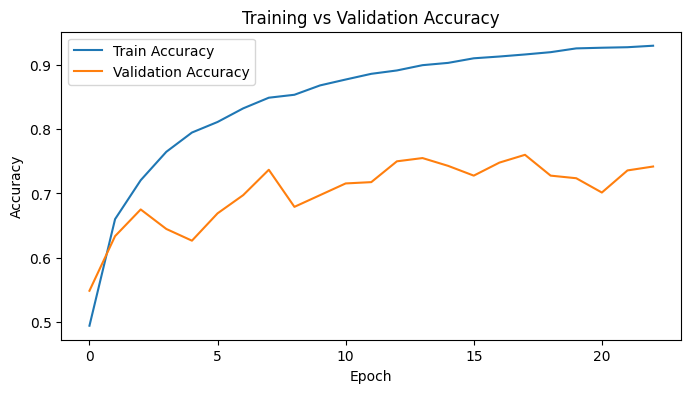

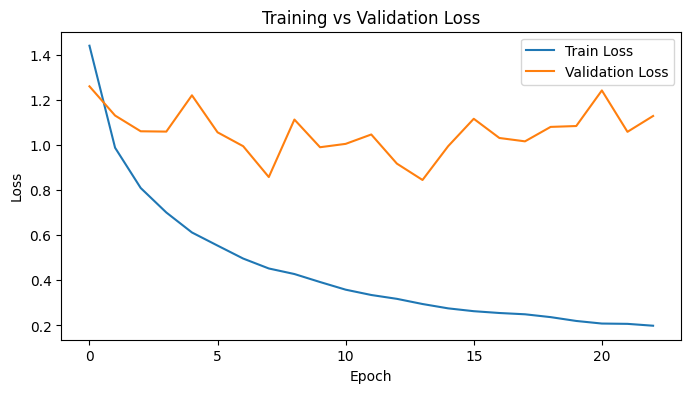

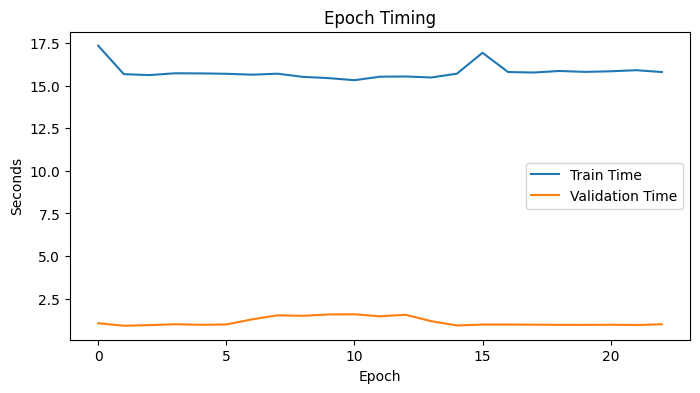

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["train_time"], label="Train Time")
plt.plot(history["val_time"], label="Validation Time")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Epoch Timing")
plt.legend()
plt.show()

## Testing

In [ ]:
best_model = CompactMusicGenreCNN1D(
    n_mels=N_MELS,
    num_classes=len(label_encoder.classes_)
).to(DEVICE)

best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

y_true, y_pred, test_time, test_energy = test_model(best_model, test_loader, DEVICE)

test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_acc)
print("Total test time:", test_time)

if test_energy is not None:
    print("Total test energy (J):", test_energy)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

Test Accuracy: 0.7222222222222222
Total test time: 2.709494471999278

Classification Report:
              precision    recall  f1-score   support

       blues       0.72      0.82      0.77       200
   classical       0.76      0.93      0.84       200
     country       0.68      0.63      0.65       200
       disco       0.72      0.64      0.68       200
      hiphop       0.76      0.78      0.77       200
        jazz       0.69      0.74      0.72       200
       metal       0.91      0.77      0.83       180
         pop       0.68      0.70      0.69       200
      reggae       0.76      0.67      0.71       200
        rock       0.58      0.55      0.56       200

    accuracy                           0.72      1980
   macro avg       0.73      0.72      0.72      1980
weighted avg       0.72      0.72      0.72      1980


Confusion Matrix:
[[165   0   9   7   1   6   1   0   2   9]
 [  0 186   4   3   0   5   1   1   0   0]
 [ 23   8 126   0   0  15   3   0   4  21]


## Features extraction for MLP and Random Forest

In [ ]:
from pathlib import Path
from IPython.display import Audio, display
import numpy as np
import pandas as pd
import joblib
import librosa

def extract_features_from_audio(audio_path, duration=3.0, sr=22050):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)

    target_len = int(duration * sr)
    if len(y) > target_len:
        y = y[:target_len]
    else:
        y = np.pad(y, (0, max(0, target_len - len(y))))

    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak

    features = {}

    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    harmony, percuss = librosa.effects.hpss(y)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    features["chroma_stft_mean"] = np.mean(chroma_stft)
    features["chroma_stft_var"] = np.var(chroma_stft)
    features["rms_mean"] = np.mean(rms)
    features["rms_var"] = np.var(rms)
    features["spectral_centroid_mean"] = np.mean(spec_cent)
    features["spectral_centroid_var"] = np.var(spec_cent)
    features["spectral_bandwidth_mean"] = np.mean(spec_bw)
    features["spectral_bandwidth_var"] = np.var(spec_bw)
    features["rolloff_mean"] = np.mean(rolloff)
    features["rolloff_var"] = np.var(rolloff)
    features["zero_crossing_rate_mean"] = np.mean(zcr)
    features["zero_crossing_rate_var"] = np.var(zcr)
    features["harmony_mean"] = np.mean(harmony)
    features["harmony_var"] = np.var(harmony)
    features["perceptr_mean"] = np.mean(percuss)
    features["perceptr_var"] = np.var(percuss)
    features["tempo"] = float(tempo)

    for i in range(20):
        features[f"mfcc{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc{i+1}_var"] = np.var(mfcc[i])

    return pd.DataFrame([features])


def prepare_audio_features(audio_path, feature_columns):
    df_features = extract_features_from_audio(audio_path)

    # Add engineered features used during training
    if 'tempo' in df_features.columns and 'rms_mean' in df_features.columns:
        df_features['tempo_energy_ratio'] = df_features['tempo'] / (df_features['rms_mean'] + 1e-6)

    if all(col in df_features.columns for col in ['spectral_centroid_mean', 'spectral_bandwidth_mean']):
        df_features['spectral_mean'] = df_features[['spectral_centroid_mean', 'spectral_bandwidth_mean']].mean(axis=1)

    if 'zero_crossing_rate_mean' in df_features.columns and 'tempo' in df_features.columns:
        df_features['zero_cross_density'] = df_features['zero_crossing_rate_mean'] * df_features['tempo']

    mfcc_mean_cols = [col for col in df_features.columns if col.startswith('mfcc') and col.endswith('_mean')]
    if mfcc_mean_cols:
        df_features['mfcc_mean'] = df_features[mfcc_mean_cols].mean(axis=1)
        df_features['mfcc_std'] = df_features[mfcc_mean_cols].std(axis=1)

    # Verify required columns exist
    missing_cols = [col for col in feature_columns if col not in df_features.columns]
    if missing_cols:
        raise ValueError(f"Missing required feature columns: {missing_cols}")

    # Match training column order
    df_features = df_features[feature_columns]

    X_new = df_features.values
    return df_features, X_new

import os
import pandas as pd
from pathlib import Path

def build_gtzan_tabular_dataframe(audio_root, duration=3.0, sr=22050):
    rows = []
    failed_files = []

    audio_root = Path(audio_root)

    genres = sorted([p for p in audio_root.iterdir() if p.is_dir()])

    for genre_dir in genres:
        label = genre_dir.name

        for audio_path in genre_dir.glob("*.wav"):
            try:
                df_feat = extract_features_from_audio(audio_path, duration=duration, sr=sr)

                # Add engineered features used during training
                if 'tempo' in df_feat.columns and 'rms_mean' in df_feat.columns:
                    df_feat['tempo_energy_ratio'] = df_feat['tempo'] / (df_feat['rms_mean'] + 1e-6)

                if all(col in df_feat.columns for col in ['spectral_centroid_mean', 'spectral_bandwidth_mean']):
                    df_feat['spectral_mean'] = df_feat[['spectral_centroid_mean', 'spectral_bandwidth_mean']].mean(axis=1)

                if 'zero_crossing_rate_mean' in df_feat.columns and 'tempo' in df_feat.columns:
                    df_feat['zero_cross_density'] = df_feat['zero_crossing_rate_mean'] * df_feat['tempo']

                mfcc_mean_cols = [col for col in df_feat.columns if col.startswith('mfcc') and col.endswith('_mean')]
                if mfcc_mean_cols:
                    df_feat['mfcc_mean'] = df_feat[mfcc_mean_cols].mean(axis=1)
                    df_feat['mfcc_std'] = df_feat[mfcc_mean_cols].std(axis=1)

                df_feat["label"] = label
                df_feat["file_path"] = str(audio_path)

                rows.append(df_feat)

            except Exception as e:
                print(f"Failed on {audio_path}: {type(e).__name__}: {e}")
                failed_files.append(str(audio_path))

    if not rows:
        raise RuntimeError("No features were extracted. Check audio_root path and input files.")

    df = pd.concat(rows, ignore_index=True)
    return df, failed_files


## MLP model

In [ ]:
import torch
import torch.nn as nn

class MGC_MLP(nn.Module):
    def __init__(self, input_dim, num_classes=10, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

## Data handling using the same precomputed log-Mel as CNN

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset

class LogMelFlattenedDataset(Dataset):
    def __init__(self, manifest_df, label_encoder, mean, std):
        self.manifest_df = manifest_df.reset_index(drop=True)
        self.label_encoder = label_encoder
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]

        x = np.load(row["feature_path"]).astype(np.float32)

        # same normalization as CNN
        x = (x - self.mean) / self.std

        # flatten [n_mels, time] -> [n_mels * time]
        x = x.reshape(-1)

        y = self.label_encoder.transform([row["label"]])[0]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

## MLP datasets from the same manifest as CNN

In [ ]:
mlp_train_dataset = LogMelFlattenedDataset(train_manifest_df, label_encoder, mean, std)
mlp_val_dataset   = LogMelFlattenedDataset(val_manifest_df, label_encoder, mean, std)
mlp_test_dataset  = LogMelFlattenedDataset(test_manifest_df, label_encoder, mean, std)

print("MLP train samples:", len(mlp_train_dataset))
print("MLP val samples:", len(mlp_val_dataset))
print("MLP test samples:", len(mlp_test_dataset))

MLP train samples: 13746
MLP val samples: 988
MLP test samples: 1980


## MLP dataloader

In [ ]:
from torch.utils.data import DataLoader

batch_size = 64
use_cuda = torch.cuda.is_available()

mlp_train_loader = DataLoader(
    mlp_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=use_cuda
)

mlp_val_loader = DataLoader(
    mlp_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=use_cuda
)

mlp_test_loader = DataLoader(
    mlp_test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=use_cuda
)

# Input dimension
sample_x, sample_y = mlp_train_dataset[0]
input_dim = sample_x.shape[0]

print("MLP input_dim:", input_dim)
print("Sample label:", sample_y)
print("MLP Train batches per epoch:", len(mlp_train_loader))
print("MLP Val batches per epoch:", len(mlp_val_loader))

MLP input_dim: 8320
Sample label: tensor(9)
MLP Train batches per epoch: 215
MLP Val batches per epoch: 16


## Initialize MLP model

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sample_x, sample_y = mlp_train_dataset[0]
input_dim = sample_x.shape[0]

print("MLP input_dim:", input_dim)

mlp_model = MGC_MLP(
    input_dim=input_dim,
    num_classes=len(label_encoder.classes_),
    dropout=0.3
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)

MLP input_dim: 8320


## MLP training loop

In [ ]:
from tqdm.auto import tqdm
import time

def train_one_epoch_mlp(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    batch_bar = tqdm(loader, desc="Training", leave=False)

    for xb, yb in batch_bar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += bs

        batch_bar.set_postfix({
            "seen": total,
            "loss": f"{total_loss / total:.4f}",
            "acc": f"{correct / total:.4f}"
        })

    elapsed = time.time() - start_time
    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, total, elapsed


def eval_one_epoch_mlp(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    batch_bar = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for xb, yb in batch_bar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            out = model(xb)
            loss = criterion(out, yb)

            bs = xb.size(0)
            total_loss += loss.item() * bs
            preds = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += bs

            batch_bar.set_postfix({
                "seen": total,
                "val_loss": f"{total_loss / total:.4f}",
                "val_acc": f"{correct / total:.4f}"
            })

    elapsed = time.time() - start_time
    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, total, elapsed

## MLP Training block

In [ ]:
mlp_best_model_path = saved_model_dir / "best_mgc_mlp_logmel.pth"

EPOCHS = 30
best_val_acc = 0.0
patience = 5
best_val_acc = 0.0
epochs_no_improve = 0
num_early_stop = 0

print("MLP Train samples:", len(mlp_train_loader.dataset))
print("MLP Val samples:", len(mlp_val_loader.dataset))
print("MLP Test samples:", len(mlp_test_loader.dataset))
print("MLP Train batches per epoch:", len(mlp_train_loader))
print("MLP Val batches per epoch:", len(mlp_val_loader))

epoch_bar = tqdm(range(EPOCHS), desc="MLP Epochs")

for epoch in epoch_bar:
    train_loss, train_acc, train_seen, train_time = train_one_epoch_mlp(
        mlp_model, mlp_train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_acc, val_seen, val_time = eval_one_epoch_mlp(
        mlp_model, mlp_val_loader, criterion, DEVICE
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(mlp_model.state_dict(), mlp_best_model_path)
    else:
        epochs_no_improve += 1

    train_sps = train_seen / train_time if train_time > 0 else 0.0
    val_sps = val_seen / val_time if val_time > 0 else 0.0

    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "train_acc": f"{train_acc:.4f}",
        "val_loss": f"{val_loss:.4f}",
        "val_acc": f"{val_acc:.4f}"
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Train Seen: {train_seen} | Val Seen: {val_seen} | "
        f"Train Time: {train_time:.2f}s | Val Time: {val_time:.2f}s | "
        f"Train Throughput: {train_sps:.2f} samples/s | "
        f"Val Throughput: {val_sps:.2f} samples/s"
    )

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        num_early_stop += 1
        break

print("Best validation accuracy:", best_val_acc)
print("Saved best MLP model to:", mlp_best_model_path)
print(f"Earlier stopping was executed: {num_early_stop} times")

MLP Train samples: 13746
MLP Val samples: 988
MLP Test samples: 1980
MLP Train batches per epoch: 215
MLP Val batches per epoch: 16


MLP Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Training:   0%|          | 0/215 [00:00<?, ?it/s]

Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 1.5878 | Train Acc: 0.4380 | Val Loss: 1.4615 | Val Acc: 0.4696 | Train Seen: 13746 | Val Seen: 988 | Train Time: 23.08s | Val Time: 1.20s | Train Throughput: 595.53 samples/s | Val Throughput: 822.89 samples/s


...

Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 9/30 | Train Loss: 0.4620 | Train Acc: 0.8424 | Val Loss: 1.5932 | Val Acc: 0.5678 | Train Seen: 13746 | Val Seen: 988 | Train Time: 24.31s | Val Time: 0.94s | Train Throughput: 565.34 samples/s | Val Throughput: 1056.01 samples/s


Training:   0%|          | 0/215 [00:00<?, ?it/s]

Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 10/30 | Train Loss: 0.4066 | Train Acc: 0.8632 | Val Loss: 1.7361 | Val Acc: 0.5455 | Train Seen: 13746 | Val Seen: 988 | Train Time: 22.89s | Val Time: 1.19s | Train Throughput: 600.44 samples/s | Val Throughput: 830.81 samples/s
Early stopping triggered.
Best validation accuracy: 0.5819838056680162
Saved best MLP model to: /content/MGC_project/saved_model/best_mgc_mlp_logmel.pth
Earlier stopping was executed: 1 times


## MLP evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

mlp_model.load_state_dict(torch.load(mlp_best_model_path, map_location=DEVICE))
mlp_model.eval()

all_preds = []
all_true = []

test_bar = tqdm(mlp_test_loader, desc="Testing")

with torch.no_grad():
    for xb, yb in test_bar:
        xb = xb.to(DEVICE, non_blocking=True)
        out = mlp_model(xb)
        preds = out.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print("Classification Report:")
print(classification_report(all_true, all_preds))

print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))

Testing:   0%|          | 0/31 [00:00<?, ?it/s]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.61      0.59       200
           1       0.77      0.77      0.77       200
           2       0.41      0.46      0.43       200
           3       0.47      0.34      0.39       200
           4       0.40      0.45      0.42       200
           5       0.50      0.61      0.55       200
           6       0.76      0.79      0.78       180
           7       0.63      0.73      0.68       200
           8       0.55      0.54      0.54       200
           9       0.39      0.21      0.27       200

    accuracy                           0.55      1980
   macro avg       0.54      0.55      0.54      1980
weighted avg       0.54      0.55      0.54      1980

Confusion Matrix:
[[123   2  20   6   4  19   6   0  14   6]
 [  8 154  14   2   4  15   0   0   3   0]
 [ 21   6  91   7   0  36   2  12  11  14]
 [ 15  11   6  67  32   1   9  30   5  24]
 [  6   2   3  23  89  11   

## MLP prediction

In [ ]:
import numpy as np
import torch
import librosa

def predict_mlp_logmel_from_audio(audio_path, model, mean, std, device):
    if isinstance(device, str):
        device = torch.device(device)

    # same preprocessing as CNN
    y, sr = librosa.load(audio_path, sr=22050, mono=True)

    target_len = 22050 * 3
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=64
    )

    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    # same normalization as CNN/MLP-logmel training
    logmel = (logmel - mean) / std

    # flatten for MLP
    x = logmel.reshape(1, -1)
    x = torch.tensor(x, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

    pred_label = label_encoder.classes_[pred_idx]
    pred_probs = probs.cpu().numpy()[0]

    return pred_label, pred_probs, logmel

## Optional batch inference benchmark

In [ ]:
import torch
from time import perf_counter as now

def benchmark_inference(model, sample_batch, device, repeat=100):
    model.eval()

    if isinstance(device, str):
        device = torch.device(device)

    sample_batch = sample_batch.to(device)

    # warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(sample_batch)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = now()

    with torch.no_grad():
        for _ in range(repeat):
            _ = model(sample_batch)

    if device.type == "cuda":
        torch.cuda.synchronize()

    end = now()

    avg_time = (end - start) / repeat
    return avg_time

sample_batch, _ = next(iter(mlp_test_loader))   # use your MLP test loader
print("sample_batch shape:", sample_batch.shape)

avg_batch_time = benchmark_inference(mlp_model, sample_batch, DEVICE, repeat=200)

print(f"Average inference time per batch: {avg_batch_time:.6f} sec")
print(f"Average inference time per sample: {avg_batch_time / sample_batch.shape[0]:.8f} sec")

sample_batch shape: torch.Size([64, 8320])
Average inference time per batch: 0.013381 sec
Average inference time per sample: 0.00020908 sec


## MACs, FLOPs, and parameter count

In [ ]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(best_model)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 54634
Trainable parameters: 54634


---

## Capture 30 seconds of music and preview the recording

This records audio from the laptop microphone in Colab, saves it as WebM, and plays it back so you can confirm the capture before conversion.


In [ ]:
from pathlib import Path
import os
import uuid

# --- Detect environment ---
try:
    from google.colab import output
    from IPython.display import Javascript, Audio, display
    IN_COLAB = True
except ImportError:
    from IPython.display import Audio, display
    IN_COLAB = False

# --- Paths ---
if IN_COLAB:
    data_dir = "/content/MGC_runtime"
else:
    data_dir = "../data/runtime"   # adjust if you want

dir_path = Path("../data/runtime/live_capture")

if not dir_path.exists():
    dir_path.mkdir(parents=True, exist_ok=True)
    print(f"The directory doesn't exist; therfore, one was created: {dir_path}")

live_dir = Path(data_dir) / "live_capture"
print(live_dir)
live_dir.mkdir(parents=True, exist_ok=True)

# --- COLAB: record audio via browser ---
if IN_COLAB:
    import base64

    RECORD_JS = '''
    async function recordAudio() {
      const stream = await navigator.mediaDevices.getUserMedia({ audio: true, video: false });
      const recorder = new MediaRecorder(stream);
      const chunks = [];

      recorder.ondataavailable = e => chunks.push(e.data);

      const stopped = new Promise(resolve => {
        recorder.onstop = resolve;
      });

      recorder.start();
      await new Promise(resolve => setTimeout(resolve, 30000));  // 30 sec
      recorder.stop();
      await stopped;

      const blob = new Blob(chunks, { type: 'audio/webm' });
      const reader = new FileReader();
      const dataUrl = await new Promise(resolve => {
        reader.onloadend = () => resolve(reader.result);
        reader.readAsDataURL(blob);
      });

      stream.getTracks().forEach(track => track.stop());
      return dataUrl;
    }
    '''

    display(Javascript(RECORD_JS))
    audio_data_url = output.eval_js("recordAudio()")

    clip_id = base64.urlsafe_b64encode(uuid.uuid4().bytes).decode()[:8]
    webm_path = live_dir / f"recording_{clip_id}.webm"

    audio_bytes = base64.b64decode(audio_data_url.split(",")[1])

    with open(webm_path, "wb") as f:
        f.write(audio_bytes)

    print("Saved recorded clip to:", webm_path)
    display(Audio(str(webm_path)))

# --- LOCAL: fallback ---
else:
    print("Running locally. Browser recording not supported here.")
    print("Please place an audio file manually in:", live_dir)

    clip_id = uuid.uuid4().hex
    example_path = live_dir / f"recording_{clip_id}.wav"

    print("Expected local filename example:", example_path)

/content/MGC_runtime/live_capture


<IPython.core.display.Javascript object>

Saved recorded clip to: /content/MGC_runtime/live_capture/recording_ohvfk18Y.webm


In [ ]:
import inspect
print(inspect.signature(predict_mlp_logmel_from_audio))

(audio_path, model, mean, std, device)


In [ ]:
def predict_mlp_logmel_from_audio(audio_path, model, mean, std, label_encoder, device):
    import numpy as np
    import torch
    import librosa

    if isinstance(device, str):
        device = torch.device(device)

    y, sr = librosa.load(audio_path, sr=22050, mono=True)

    target_len = 22050 * 3
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=64
    )

    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    logmel = (logmel - mean) / std

    x = logmel.reshape(1, -1)
    x = torch.tensor(x, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

    pred_label = label_encoder.classes_[pred_idx]
    pred_probs = probs.cpu().numpy()[0]

    return pred_label, pred_probs, logmel

### 23. Convert captured audio to WAV

In [ ]:
from pathlib import Path
import subprocess
import os

# -----------------------------------
# Detect environment
# -----------------------------------
IN_COLAB = os.path.exists("/content")

if IN_COLAB:
    base_runtime = Path("/content/MGC_runtime")
else:
    base_runtime = Path.cwd() / "data" / "runtime"

live_dir = base_runtime / "live_capture"
live_dir.mkdir(parents=True, exist_ok=True)

print("Running in:", "Colab" if IN_COLAB else "Local")
print("Live dir:", live_dir)

# -----------------------------------
# WAV conversion
# -----------------------------------
def ensure_wav(audio_path, output_dir):
    audio_path = Path(audio_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if not audio_path.exists():
        print("File does not exist:", audio_path)
        return None

    suffix = audio_path.suffix.lower()

    if suffix == ".wav":
        print("Already WAV file. Skipping conversion.")
        return audio_path

    elif suffix == ".webm":
        wav_path = output_dir / (audio_path.stem + ".wav")

        try:
            subprocess.run(
                [
                    "ffmpeg", "-y",
                    "-i", str(audio_path),
                    "-ac", "1",
                    "-ar", "22050",
                    "-c:a", "pcm_s16le",
                    str(wav_path)
                ],
                check=True,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )

            print("Converted to:", wav_path)
            return wav_path

        except subprocess.CalledProcessError:
            print("ffmpeg failed to convert:", audio_path)
            return None

    else:
        print(f"Unsupported format: {suffix}")
        return None


# -----------------------------------
# Get latest audio file
# -----------------------------------
def get_latest_audio_file(folder):
    folder = Path(folder)

    if not folder.exists():
        print("Folder does not exist:", folder)
        return None

    files = []
    for ext in ("*.wav", "*.webm"):
        files.extend(folder.glob(ext))

    if not files:
        print("No audio files found.")
        return None

    latest = max(files, key=lambda f: f.stat().st_mtime)
    return latest


# -----------------------------------
# MAIN PIPELINE
# -----------------------------------
audio_input = get_latest_audio_file(live_dir)

# Align label encoder (assuming same class order)
if 'cnn_label_encoder' in globals():
    mlp_label_encoder = cnn_label_encoder
elif 'label_encoder' in globals():
    mlp_label_encoder = label_encoder
else:
    raise ValueError("No label encoder found. Load one before prediction.")

if audio_input is None:
    print("No file to process.")
else:
    print("Using audio file:", audio_input)

    wav_path = ensure_wav(audio_input, live_dir)
    print("WAV path:", wav_path)

    if wav_path is not None:
        pred_label, pred_probs, logmel_features = predict_mlp_logmel_from_audio(
            wav_path,
            mlp_model,
            mean,
            std,
            mlp_label_encoder,   # <-- FIXED (you were missing this)
            DEVICE
        )

        print("Predicted:", pred_label)
    else:
        print("Prediction skipped due to invalid audio.")

Running in: Colab
Live dir: /content/MGC_runtime/live_capture
Using audio file: /content/MGC_runtime/live_capture/recording_ohvfk18Y.webm
Converted to: /content/MGC_runtime/live_capture/recording_ohvfk18Y.wav
WAV path: /content/MGC_runtime/live_capture/recording_ohvfk18Y.wav
Predicted: classical


## MLP prediction

In [ ]:
import numpy as np
import torch
import librosa

def predict_mlp_logmel_from_audio(audio_path, model, mean, std, label_encoder, device):
    if isinstance(device, str):
        device = torch.device(device)

    y, sr = librosa.load(audio_path, sr=22050, mono=True)

    target_len = 22050 * 3
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=64
    )

    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    # same normalization as training
    logmel = (logmel - mean) / std

    # flatten for MLP
    x = logmel.reshape(1, -1)
    x = torch.tensor(x, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

    pred_label = label_encoder.classes_[pred_idx]
    mlp_probs = probs.cpu().numpy()[0]

    return pred_label, mlp_probs, logmel

mlp_label_encoder = label_encoder   # or cnn_label_encoder if that matches training

wav_path = ensure_wav(audio_input, live_dir)
print("WAV path:", wav_path)

pred_label, mlp_probs, logmel_features = predict_mlp_logmel_from_audio(
    wav_path,
    mlp_model,
    mean,
    std,
    mlp_label_encoder,
    DEVICE
)

print("Predicted Genre:", pred_label)
print("Probabilities:", mlp_probs)
print("Log-mel shape:", logmel_features.shape)

Converted to: /content/MGC_runtime/live_capture/recording_ohvfk18Y.wav
WAV path: /content/MGC_runtime/live_capture/recording_ohvfk18Y.wav
Predicted Genre: classical
Probabilities: [7.99558693e-05 3.35522205e-01 2.03413097e-03 3.26484203e-01
 1.15360618e-02 9.36666183e-05 6.62208423e-02 1.37818104e-03
 1.38194114e-01 1.18456684e-01]
Log-mel shape: (64, 130)


## Build RF matrices from the same manifest as MLP and CNN

In [ ]:
import numpy as np
from tqdm.auto import tqdm

def build_flattened_logmel_matrix(manifest_df, label_encoder, mean, std):
    X_list = []
    y_list = []

    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc="Building RF matrix"):
        x = np.load(row["feature_path"]).astype(np.float32)

        # same normalization as CNN / MLP
        x = (x - mean) / std

        # flatten [n_mels, time] -> [n_mels * time]
        x = x.reshape(-1)

        y = label_encoder.transform([row["label"]])[0]

        X_list.append(x)
        y_list.append(y)

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)

    return X, y

## Create train/val/test from the same segmented data

In [ ]:
X_train_rf, y_train_rf = build_flattened_logmel_matrix(train_manifest_df, label_encoder, mean, std)
X_val_rf, y_val_rf     = build_flattened_logmel_matrix(val_manifest_df, label_encoder, mean, std)
X_test_rf, y_test_rf   = build_flattened_logmel_matrix(test_manifest_df, label_encoder, mean, std)

print("RF train shape:", X_train_rf.shape, y_train_rf.shape)
print("RF val shape:", X_val_rf.shape, y_val_rf.shape)
print("RF test shape:", X_test_rf.shape, y_test_rf.shape)

Building RF matrix:   0%|          | 0/13746 [00:00<?, ?it/s]

Building RF matrix:   0%|          | 0/988 [00:00<?, ?it/s]

Building RF matrix:   0%|          | 0/1980 [00:00<?, ?it/s]

RF train shape: (13746, 8320) (13746,)
RF val shape: (988, 8320) (988,)
RF test shape: (1980, 8320) (1980,)


## Random forest model

In [ ]:
import os
import shutil
import joblib
from sklearn.ensemble import RandomForestClassifier

def get_or_create_rf_bundle(
    X_train,
    y_train,
    label_encoder,
    local_rf_dir,
    bundle_filename="rf_bundle_logmel.pkl",
    drive_rf_dir=None,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
):
    os.makedirs(local_rf_dir, exist_ok=True)

    local_bundle_path = os.path.join(local_rf_dir, bundle_filename)

    drive_bundle_path = None
    if drive_rf_dir is not None:
        os.makedirs(drive_rf_dir, exist_ok=True)
        drive_bundle_path = os.path.join(drive_rf_dir, bundle_filename)

    # 1) Prefer local bundle if it exists
    if os.path.exists(local_bundle_path):
        print(f"Found RF bundle locally: {local_bundle_path}")
        return joblib.load(local_bundle_path)

    # 2) Otherwise try Drive bundle if available
    if drive_bundle_path is not None and os.path.exists(drive_bundle_path):
        print(f"Found RF bundle on Drive: {drive_bundle_path}")
        bundle = joblib.load(drive_bundle_path)
        shutil.copy2(drive_bundle_path, local_bundle_path)
        print(f"Copied RF bundle locally: {local_bundle_path}")
        return bundle

    # 3) Train a new RF model
    print("No RF bundle found. Training a new RF model...")
    print("RF n_jobs:", rf_model.n_jobs)

    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    bundle = {
        "model": rf_model,
        "label_encoder": label_encoder
    }

    joblib.dump(bundle, local_bundle_path)
    print(f"Saved RF bundle locally: {local_bundle_path}")

    if drive_bundle_path is not None:
        joblib.dump(bundle, drive_bundle_path)
        print(f"Saved RF bundle to Drive: {drive_bundle_path}")

    return bundle

## For using this data locally

In [ ]:
rf_bundle = get_or_create_rf_bundle(
    X_train=X_train_rf,
    y_train=y_train_rf,
    label_encoder=label_encoder,
    local_rf_dir=str(saved_model_dir),
    bundle_filename="rf_bundle_logmel.pkl",
    drive_rf_dir=None
)

rf_model = rf_bundle["model"]
label_encoder = rf_bundle["label_encoder"]

Found RF bundle locally: /content/MGC_project/saved_model/rf_bundle_logmel.pkl


## For using data in Colab

In [ ]:
drive_rf_dir = None
if IN_COLAB:
    drive_rf_dir = "/content/drive/MyDrive/Colab Notebooks/CAI 6106/MGC_runtime/saved_model"

rf_bundle = get_or_create_rf_bundle(
    X_train=X_train_rf,
    y_train=y_train_rf,
    label_encoder=label_encoder,
    local_rf_dir=str(saved_model_dir),
    bundle_filename="rf_bundle_logmel.pkl",
    drive_rf_dir=drive_rf_dir
)

Found RF bundle locally: /content/MGC_project/saved_model/rf_bundle_logmel.pkl


## Random Forest - prediction

In [ ]:
import numpy as np
import librosa

def predict_rf_logmel_from_audio(audio_path, rf_model, mean, std, label_encoder):
    y, sr = librosa.load(audio_path, sr=22050, mono=True)

    target_len = 22050 * 3
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=64
    )

    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    logmel = (logmel - mean) / std

    x = logmel.reshape(1, -1)

    probs = rf_model.predict_proba(x)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    confidence = float(np.max(probs))

    sorted_idx = np.argsort(probs)[::-1]
    top2 = sorted_idx[1] if len(sorted_idx) > 1 else sorted_idx[0]
    margin = float(probs[pred_idx] - probs[top2])

    return pred_label, confidence, margin, probs, logmel

rf_bundle = get_or_create_rf_bundle(
    X_train=X_train_rf,
    y_train=y_train_rf,
    label_encoder=label_encoder,
    local_rf_dir=str(saved_model_dir),
    bundle_filename="rf_bundle_logmel.pkl",
    drive_rf_dir=None
)

rf_model = rf_bundle["model"]
rf_label_encoder = rf_bundle["label_encoder"]

rf_label, rf_conf, rf_margin, rf_probs, rf_logmel = predict_rf_logmel_from_audio(
    wav_path,
    rf_model,
    mean,
    std,
    rf_label_encoder
)

print("RF Predicted Genre:", rf_label)
print("RF Confidence:", rf_conf)
print("RF Margin:", rf_margin)

Found RF bundle locally: /content/MGC_project/saved_model/rf_bundle_logmel.pkl
RF Predicted Genre: disco
RF Confidence: 0.15
RF Margin: 0.0050000000000000044


## Extract feature for CNN

In [ ]:
import numpy as np
import librosa
import torch

def extract_logmel_segments_for_cnn(audio_path, mean, std, duration=3.0, sr=22050,
                                    n_fft=2048, hop_length=512, n_mels=64):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)

    samples_per_clip = int(duration * sr)
    segments = []

    for start in range(0, len(y), samples_per_clip):
        segment = y[start:start + samples_per_clip]

        if len(segment) < samples_per_clip:
            break

        peak = np.max(np.abs(segment))
        if peak > 0:
            segment = segment / peak

        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

        logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

        # Match training normalization
        logmel = (logmel - mean) / std

        segments.append(logmel)

    return segments

def predict_cnn_from_audio(audio_path, model, label_encoder, mean, std, device):
    model.eval()

    segments = extract_logmel_segments_for_cnn(
        audio_path=audio_path,
        mean=mean,
        std=std
    )

    if len(segments) == 0:
        raise ValueError("No valid 3-second segments were extracted from the audio.")

    preds = []
    probs_all = []

    with torch.no_grad():
        for seg in segments:
            x = torch.tensor(seg, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)
            pred = torch.argmax(probs, dim=1).item()

            preds.append(pred)
            probs_all.append(probs.cpu().numpy()[0])

    # Average probabilities across segments
    avg_probs = np.mean(probs_all, axis=0)
    final_pred = int(np.argmax(avg_probs))
    final_label = label_encoder.classes_[final_pred]

    return final_label, avg_probs, preds

## CNN prediction

In [ ]:
import numpy as np
import torch
import librosa

def predict_cnn_from_audio(audio_path, model, mean, std, label_encoder, device):
    if isinstance(device, str):
        device = torch.device(device)

    # -----------------------
    # Load audio
    # -----------------------
    y, sr = librosa.load(audio_path, sr=22050, mono=True)

    target_len = 22050 * 3
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # -----------------------
    # Log-Mel extraction
    # -----------------------
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=64
    )

    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    # -----------------------
    # Normalize
    # -----------------------
    logmel = (logmel - mean) / std

    # -----------------------
    # CNN expects: [B, C, T]
    # -----------------------
    x = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0).to(device)
    # shape → [1, 64, time]

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

    pred_label = label_encoder.classes_[pred_idx]
    cnn_probs = probs.cpu().numpy()[0]

    return pred_label, cnn_probs, logmel

cnn_label_encoder = label_encoder   # or your saved CNN encoder

import torch
from pathlib import Path

# Path to your saved model
cnn_weights_path = Path(saved_model_dir) / "cnn_models/best_mgc_student_1dcnn_logmel.pth"

# Recreate model (must match training architecture)
cnn_model = CompactMusicGenreCNN1D(
    n_mels=N_MELS,
    num_classes=len(label_encoder.classes_)
).to(DEVICE)

# Load weights
state_dict = torch.load(cnn_weights_path, map_location=DEVICE)
cnn_model.load_state_dict(state_dict)

cnn_model.eval()

print("CNN model loaded from:", cnn_weights_path)

pred_label, cnn_probs, logmel = predict_cnn_from_audio(
    wav_path,
    cnn_model,
    mean,
    std,
    cnn_label_encoder,
    DEVICE
)

print("CNN Predicted Genre:", pred_label)
print("CNN Probabilities:", cnn_probs)
print("Log-mel shape:", logmel.shape)

CNN model loaded from: /content/MGC_project/saved_model/cnn_models/best_mgc_student_1dcnn_logmel.pth
CNN Predicted Genre: metal
CNN Probabilities: [8.7238599e-09 3.2987984e-05 1.3386700e-08 9.1712724e-04 7.1285853e-05
 1.7630819e-08 9.9430120e-01 1.1206558e-07 4.1203376e-07 4.6768580e-03]
Log-mel shape: (64, 130)


## CNN preprocessing for ensemble prediction

In [ ]:
def preprocess_audio_for_cnn(audio_path, mean, std, sr=SR):
    y, sr_loaded, err = load_audio_safe(audio_path, sr=sr)

    if err is not None:
        raise RuntimeError(f"Failed to load audio for CNN: {err}")

    if len(y) < WINDOW_SAMPLES:
        y = np.pad(y, (0, WINDOW_SAMPLES - len(y)))
    else:
        y = y[:WINDOW_SAMPLES]

    log_mel = compute_log_mel_spectrogram(y)   # shape [64, time_frames]
    log_mel = (log_mel - mean) / std

    x = torch.tensor(log_mel, dtype=torch.float32).unsqueeze(0)  # [1, 64, time_frames]
    return x

## Ensemble function

In [ ]:
import numpy as np
import pandas as pd
import torch

def predict_ensemble_rf_cnn_mlp(
    audio_path,
    rf_model,
    rf_mean,
    rf_std,
    rf_label_encoder,
    cnn_model,
    cnn_mean,
    cnn_std,
    cnn_label_encoder,
    mlp_model,
    mlp_mean,
    mlp_std,
    mlp_label_encoder,
    device,
    rf_weight=1.0,
    cnn_weight=1.0,
    mlp_weight=1.0
):
    # -----------------------------------
    # Normalize device
    # -----------------------------------
    if isinstance(device, str):
        device = torch.device(device)

    # -----------------------------------
    # RF prediction (log-mel RF)
    # returns: pred_label, confidence, margin, probs, logmel
    # -----------------------------------
    rf_label, rf_conf, rf_margin, rf_probs, rf_logmel = predict_rf_logmel_from_audio(
        audio_path=audio_path,
        rf_model=rf_model,
        mean=rf_mean,
        std=rf_std,
        label_encoder=rf_label_encoder
    )

    # -----------------------------------
    # CNN prediction
    # returns: pred_label, pred_probs, logmel
    # -----------------------------------
    cnn_label, cnn_probs, cnn_logmel = predict_cnn_from_audio(
        audio_path=audio_path,
        model=cnn_model,
        mean=cnn_mean,
        std=cnn_std,
        label_encoder=cnn_label_encoder,
        device=device
    )

    cnn_conf = float(np.max(cnn_probs))
    cnn_sorted = np.argsort(cnn_probs)[::-1]
    cnn_margin = float(cnn_probs[cnn_sorted[0]] - cnn_probs[cnn_sorted[1]]) if len(cnn_sorted) > 1 else float(cnn_probs[cnn_sorted[0]])

    # -----------------------------------
    # MLP prediction (log-mel MLP)
    # returns: pred_label, pred_probs, logmel
    # -----------------------------------
    mlp_label, mlp_probs, mlp_logmel = predict_mlp_logmel_from_audio(
        audio_path=audio_path,
        model=mlp_model,
        mean=mlp_mean,
        std=mlp_std,
        label_encoder=mlp_label_encoder,
        device=device
    )

    mlp_conf = float(np.max(mlp_probs))
    mlp_sorted = np.argsort(mlp_probs)[::-1]
    mlp_margin = float(mlp_probs[mlp_sorted[0]] - mlp_probs[mlp_sorted[1]]) if len(mlp_sorted) > 1 else float(mlp_probs[mlp_sorted[0]])

    # -----------------------------------
    # Safety check: class order must match
    # -----------------------------------
    if list(rf_label_encoder.classes_) != list(cnn_label_encoder.classes_):
        raise ValueError("RF and CNN label encoders do not match in class order.")

    if list(rf_label_encoder.classes_) != list(mlp_label_encoder.classes_):
        raise ValueError("RF and MLP label encoders do not match in class order.")

    # -----------------------------------
    # Weighted ensemble
    # -----------------------------------
    total_weight = rf_weight + cnn_weight + mlp_weight
    if total_weight <= 0:
        raise ValueError("Sum of ensemble weights must be > 0.")

    ensemble_probs = (
        (rf_weight * rf_probs) +
        (cnn_weight * cnn_probs) +
        (mlp_weight * mlp_probs)
    ) / total_weight

    ensemble_idx = int(np.argmax(ensemble_probs))
    ensemble_label = rf_label_encoder.inverse_transform([ensemble_idx])[0]
    ensemble_conf = float(np.max(ensemble_probs))

    ensemble_sorted = np.argsort(ensemble_probs)[::-1]
    ensemble_margin = float(ensemble_probs[ensemble_sorted[0]] - ensemble_probs[ensemble_sorted[1]]) if len(ensemble_sorted) > 1 else float(ensemble_probs[ensemble_sorted[0]])

    # -----------------------------------
    # Results table
    # -----------------------------------
    results = pd.DataFrame({
        "audio_file": [str(audio_path)],

        "rf_prediction": [rf_label],
        "rf_confidence": [rf_conf],
        "rf_margin": [rf_margin],

        "cnn_prediction": [cnn_label],
        "cnn_confidence": [cnn_conf],
        "cnn_margin": [cnn_margin],

        "mlp_prediction": [mlp_label],
        "mlp_confidence": [mlp_conf],
        "mlp_margin": [mlp_margin],

        "ensemble_prediction": [ensemble_label],
        "ensemble_confidence": [ensemble_conf],
        "ensemble_margin": [ensemble_margin]
    })

    # Per-class probabilities
    for genre, rf_p, cnn_p, mlp_p, ens_p in zip(
        rf_label_encoder.classes_,
        rf_probs,
        cnn_probs,
        mlp_probs,
        ensemble_probs
    ):
        results[f"rf_prob_{genre}"] = rf_p
        results[f"cnn_prob_{genre}"] = cnn_p
        results[f"mlp_prob_{genre}"] = mlp_p
        results[f"ensemble_prob_{genre}"] = ens_p

    print("\nRandom Forest prediction:")
    print(f"  Label      : {rf_label}")
    print(f"  Confidence : {rf_conf:.4f}")
    print(f"  Margin     : {rf_margin:.4f}")

    print("\nCNN prediction:")
    print(f"  Label      : {cnn_label}")
    print(f"  Confidence : {cnn_conf:.4f}")
    print(f"  Margin     : {cnn_margin:.4f}")

    print("\nMLP prediction:")
    print(f"  Label      : {mlp_label}")
    print(f"  Confidence : {mlp_conf:.4f}")
    print(f"  Margin     : {mlp_margin:.4f}")

    print("\nEnsemble prediction:")
    print(f"  Label      : {ensemble_label}")
    print(f"  Confidence : {ensemble_conf:.4f}")
    print(f"  Margin     : {ensemble_margin:.4f}")

    return results

## Final prediction

In [ ]:
results = predict_ensemble_rf_cnn_mlp(
    audio_path=wav_path,

    rf_model=rf_model,
    rf_mean=mean,
    rf_std=std,
    rf_label_encoder=rf_label_encoder,

    cnn_model=cnn_model,
    cnn_mean=mean,
    cnn_std=std,
    cnn_label_encoder=cnn_label_encoder,

    mlp_model=mlp_model,
    mlp_mean=mean,
    mlp_std=std,
    mlp_label_encoder=mlp_label_encoder,

    device=DEVICE,
    rf_weight=1.0,
    cnn_weight=1.0,
    mlp_weight=1.0
)

print(results.T)


Random Forest prediction:
  Label      : disco
  Confidence : 0.1500
  Margin     : 0.0050

CNN prediction:
  Label      : metal
  Confidence : 0.9943
  Margin     : 0.9896

MLP prediction:
  Label      : classical
  Confidence : 0.3355
  Margin     : 0.0090

Ensemble prediction:
  Label      : metal
  Confidence : 0.3868
  Margin     : 0.2277
                                                                         0
audio_file               /content/MGC_runtime/live_capture/recording_oh...
rf_prediction                                                        disco
rf_confidence                                                         0.15
rf_margin                                                            0.005
cnn_prediction                                                       metal
cnn_confidence                                                    0.994301
cnn_margin                                                        0.989624
mlp_prediction                                       

## Probability and degree of confidence

In [ ]:
def format_probs_with_confidence(probs, label_encoder, top_k=None):
    classes = list(label_encoder.classes_)
    pairs = list(zip(classes, probs))

    # Sort descending
    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)

    # Top predictions
    top_pairs = pairs[:top_k] if top_k else pairs

    # Confidence metrics
    top1_label, top1_prob = pairs[0]
    top2_prob = pairs[1][1] if len(pairs) > 1 else 0.0

    confidence = float(top1_prob)
    margin = float(top1_prob - top2_prob)

    return {
        "top_predictions": top_pairs,
        "top_label": top1_label,
        "confidence": confidence,
        "margin": margin
    }

def print_probs_with_confidence(probs, label_encoder, title="Model", top_k=5):
    result = format_probs_with_confidence(probs, label_encoder, top_k=top_k)

    print(f"\n{title} Prediction:")
    print(f"  Top-1 Label : {result['top_label']}")
    print(f"  Confidence  : {result['confidence']:.4f}")
    print(f"  Margin      : {result['margin']:.4f}")

    if result["confidence"] < 0.2:
        print("Low confidence")
    if result["margin"] < 0.02:
        print("Weak separation between classes")

    print(f"\n  Top-{top_k} Probabilities:")
    for label, p in result["top_predictions"]:
        print(f"    {label:10s}: {p:.4f}")

import numpy as np

def entropy(probs):
    probs = np.clip(probs, 1e-9, 1.0)
    return -np.sum(probs * np.log(probs))

print_probs_with_confidence(results.filter(like="rf_prob_").values[0], rf_label_encoder, "RF", top_k=5)
print_probs_with_confidence(results.filter(like="cnn_prob_").values[0], cnn_label_encoder, "CNN", top_k=5)
print_probs_with_confidence(results.filter(like="mlp_prob_").values[0], mlp_label_encoder, "MLP", top_k=5)
print_probs_with_confidence(results.filter(like="ensemble_prob_").values[0], rf_label_encoder, "Ensemble", top_k=5)


RF Prediction:
  Top-1 Label : hiphop
  Confidence  : 0.2300
  Margin      : 0.0800

  Top-5 Probabilities:
    hiphop    : 0.2300
    disco     : 0.1500
    reggae    : 0.1500
    jazz      : 0.1150
    classical : 0.1050

CNN Prediction:
  Top-1 Label : disco
  Confidence  : 0.5455
  Margin      : 0.3316

  Top-5 Probabilities:
    disco     : 0.5455
    rock      : 0.2139
    metal     : 0.1997
    hiphop    : 0.0388
    blues     : 0.0005

MLP Prediction:
  Top-1 Label : disco
  Confidence  : 0.4514
  Margin      : 0.2263

  Top-5 Probabilities:
    disco     : 0.4514
    metal     : 0.2252
    classical : 0.1326
    hiphop    : 0.1157
    rock      : 0.0410

Ensemble Prediction:
  Top-1 Label : disco
  Confidence  : 0.3823
  Margin      : 0.2324

  Top-5 Probabilities:
    disco     : 0.3823
    metal     : 0.1499
    hiphop    : 0.1282
    rock      : 0.0966
    classical : 0.0793


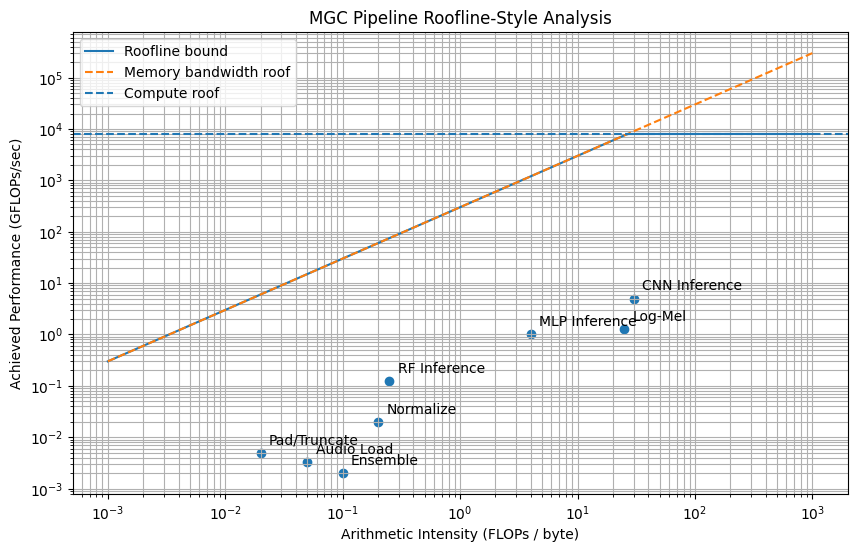

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example hardware limits — replace with your actual system/GPU values
peak_gflops = 8000        # example GPU peak compute
memory_bw_gbs = 300       # example GPU memory bandwidth

# Estimated per-stage values
# Replace these with profiled/measured values later
stages = {
    "Audio Load":       {"flops": 1e5,   "bytes": 2e6,   "time": 0.030},
    "Pad/Truncate":     {"flops": 1e4,   "bytes": 5e5,   "time": 0.002},
    "Log-Mel":          {"flops": 5e7,   "bytes": 2e6,   "time": 0.040},
    "Normalize":        {"flops": 2e4,   "bytes": 1e5,   "time": 0.001},
    "CNN Inference":    {"flops": 3e7,   "bytes": 1e6,   "time": 0.006},
    "RF Inference":     {"flops": 5e5,   "bytes": 2e6,   "time": 0.004},
    "MLP Inference":    {"flops": 2e6,   "bytes": 5e5,   "time": 0.002},
    "Ensemble":         {"flops": 1e3,   "bytes": 1e4,   "time": 0.0005},
}

ai = []
perf = []
labels = []

for name, v in stages.items():
    arithmetic_intensity = v["flops"] / v["bytes"]          # FLOPs/byte
    achieved_gflops = (v["flops"] / v["time"]) / 1e9        # GFLOPs/sec

    ai.append(arithmetic_intensity)
    perf.append(achieved_gflops)
    labels.append(name)

x = np.logspace(-3, 3, 300)
roof_memory = memory_bw_gbs * x
roof_compute = np.full_like(x, peak_gflops)
roof = np.minimum(roof_memory, roof_compute)

plt.figure(figsize=(10, 6))
plt.loglog(x, roof, label="Roofline bound")
plt.loglog(x, roof_memory, linestyle="--", label="Memory bandwidth roof")
plt.axhline(peak_gflops, linestyle="--", label="Compute roof")

plt.scatter(ai, perf)

for i, label in enumerate(labels):
    plt.annotate(label, (ai[i], perf[i]), textcoords="offset points", xytext=(6, 6))

plt.xlabel("Arithmetic Intensity (FLOPs / byte)")
plt.ylabel("Achieved Performance (GFLOPs/sec)")
plt.title("MGC Pipeline Roofline-Style Analysis")
plt.grid(True, which="both")
plt.legend()
plt.show()

### 6. Pseudocode for 1D CNN for GTZAN

Algorithm: GTZAN 1D CNN Music Genre Classification

Input:

    features_3_sec.csv

Output:

    Predicted music genre for each sample

    Final test accuracy

    CPU/GPU performance metrics

Begin

1. Load Dataset

    Read features_3_sec.csv into memory

2. Preprocess Data

    Remove metadata columns:

        filename, length, label

    Store remaining numerical columns as X

    Store label column as y

3. Encode Labels

    Convert genre names into integer class indices

        blues → 0

        classical → 1

        ...

        rock → 9

4. Split Dataset

    Divide data into:

        70% training

        15% validation

        15% test

5. Standardize Features

    Compute mean and standard deviation from training set

    Standardize training set using training mean/std

    Standardize validation set using same training mean/std

    Standardize test set using same training mean/std

6. Reshape for 1D CNN

    Convert X_train, X_val, X_test into tensor format

    Reshape each sample to:

        (channels = 1, sequence_length = 57)

7. Create Mini-batches

    Build training DataLoader with batch_size

    Build validation DataLoader

    Build test DataLoader

8. Define 1D CNN Model

    Input: normalized feature vector

    Layer 1:

        Conv1D

        ReLU

        MaxPool1D

    Layer 2:

        Conv1D

        ReLU

        MaxPool1D

    Flatten output

    Fully connected dense layer

    Dropout

    Output dense layer with 10 neurons

    Softmax used implicitly through cross-entropy loss

9. Initialize Training Settings

    Set learning rate

    Set optimizer = Adam

    Set loss function = CrossEntropyLoss

    Set number of epochs

    Initialize best validation accuracy = 0

10. Train Model

    For epoch = 1 to num_epochs:

        Set model to training mode

        For each batch in training DataLoader:

            Forward pass:

                compute predicted logits

            Compute loss using cross-entropy

            Backward pass:

                compute gradients

            Update weights using Adam optimizer

        Set model to evaluation mode

        Evaluate model on validation set

        Compute validation accuracy

        If validation accuracy > best validation accuracy:

            Save current model as best model

            Update best validation accuracy

11. Test Best Model

    Load best saved model

    Set model to evaluation mode

    Run inference on test DataLoader

    Compute test accuracy

    Record predicted genres

12. Benchmark Hardware

    Measure:

        training time per epoch

        total training time

        inference latency

        inference throughput

    Repeat experiment on CPU and GPU
    
    Compare results

End